In [1]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
import pandas as pd
import numpy as np

# Synthetic customer data designed to contain 3 natural segments:
#   - Young customers, low spend, few orders   (Age ~21-26, Spend ~800-1200)
#   - Mid-age customers, moderate spend         (Age ~33-40, Spend ~2500-3100)
#   - Senior customers, high spend, frequent orders (Age ~50-62, Spend ~4600-5200)
# City happens to line up with these segments (Giza/Cairo/Alex) purely for this
# synthetic example, which helps the clustering algorithms separate them cleanly.
# The data also keeps a few intentional data-quality issues (a duplicate row,
# a missing value, a negative value, inconsistent 'M'/'F' labels, and a name
# with leading whitespace) so the cleaning steps below have something to fix.
data = {
    'Customer_ID': [101, 102, 103, 104, 105, 105, 107, 108, 109, 110, 111, 112, 113, 114, 115],
    'Name': ['Ahmed Ali', 'Sara Mohamed', '   Mona Mahmoud', 'Omar Hassan', 'Khaled Said', 'Khaled Said', 'Youssef Amr', 'Nour Eslam', 'Hassan Ali', 'Fatma Ibrahim', 'Eslam Ahmed', 'Mariam Said', 'Kareem Tarek', 'Hoda Tamer', 'Ayman Noor'],
    'Age': [24, 23, 25, 21, 35, 35, 38, 26, 33, 40, 55, 58, 62, 50, 60],
    'Gender': ['Male', 'Female', 'Female', 'M', 'Male', 'Male', 'Male', 'F', 'Male', 'Female', 'Male', 'Female', 'M', 'Female', 'Male'],
    'City': ['Giza', 'Giza', 'Giza', 'Giza', 'Cairo', 'Cairo', 'Cairo', 'Giza', 'Cairo', 'Cairo', 'Alex', 'Alex', 'Alex', 'Alex', 'Alex'],
    'Total_Spend': [950.0, 1100.0, 1050.0, 800.0, 2600.0, 2600.0, -2900.0, 1200.0, 3100.0, np.nan, 4800.0, 5200.0, 4600.0, 5000.0, 4700.0],
    'Orders_Count': [3, 2, 4, 1, 7, 7, 8, 3, 9, 6, 13, 15, 12, 14, 12]
}

df = pd.DataFrame(data)


In [3]:
df.head()

,Customer_ID,Name,Age,Gender,City,Total_Spend,Orders_Count
0,101,Ahmed Ali,24,Male,Giza,950.0,3
1,102,Sara Mohamed,23,Female,Giza,1100.0,2
2,103,Mona Mahmoud,25,Female,Giza,1050.0,4
3,104,Omar Hassan,21,M,Giza,800.0,1
4,105,Khaled Said,35,Male,Cairo,2600.0,7


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Customer_ID   15 non-null     int64  
 1   Name          15 non-null     str    
 2   Age           15 non-null     int64  
 3   Gender        15 non-null     str    
 4   City          15 non-null     str    
 5   Total_Spend   14 non-null     float64
 6   Orders_Count  15 non-null     int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 1.2 KB


In [5]:
df.describe().astype(int)

,Customer_ID,Age,Total_Spend,Orders_Count
count,15,15,14,15
mean,107,39,2485,7
std,4,14,2298,4
min,101,21,-2900,1
25%,104,25,1062,3
50%,108,35,2600,7
75%,111,52,4675,12
max,115,62,5200,15


In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df=df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Customer_ID     0
Name            0
Age             0
Gender          0
City            0
Total_Spend     1
Orders_Count    0
dtype: int64

In [10]:
df['Total_Spend'] = df['Total_Spend'].fillna(df['Total_Spend'].mean())

In [11]:
df.isnull().sum()

Customer_ID     0
Name            0
Age             0
Gender          0
City            0
Total_Spend     0
Orders_Count    0
dtype: int64

In [12]:
df.columns = df.columns.str.strip()

In [13]:
df['Gender'] = df['Gender'].replace({
    'M': 'Male',
    'F': 'Female',
})

In [14]:
df.head(15)

,Customer_ID,Name,Age,Gender,City,Total_Spend,Orders_Count
0,101,Ahmed Ali,24,Male,Giza,950.000000,3
1,102,Sara Mohamed,23,Female,Giza,1100.000000,2
2,103,Mona Mahmoud,25,Female,Giza,1050.000000,4
3,104,Omar Hassan,21,Male,Giza,800.000000,1
4,105,Khaled Said,35,Male,Cairo,2600.000000,7
6,107,Youssef Amr,38,Male,Cairo,-2900.000000,8
7,108,Nour Eslam,26,Female,Giza,1200.000000,3
8,109,Hassan Ali,33,Male,Cairo,3100.000000,9
9,110,Fatma Ibrahim,40,Female,Cairo,2476.923077,6
10,111,Eslam Ahmed,55,Male,Alex,4800.000000,13


In [15]:
df['Total_Spend'] = df['Total_Spend'].abs().astype(int)

In [16]:
df.head(15)

,Customer_ID,Name,Age,Gender,City,Total_Spend,Orders_Count
0,101,Ahmed Ali,24,Male,Giza,950,3
1,102,Sara Mohamed,23,Female,Giza,1100,2
2,103,Mona Mahmoud,25,Female,Giza,1050,4
3,104,Omar Hassan,21,Male,Giza,800,1
4,105,Khaled Said,35,Male,Cairo,2600,7
6,107,Youssef Amr,38,Male,Cairo,2900,8
7,108,Nour Eslam,26,Female,Giza,1200,3
8,109,Hassan Ali,33,Male,Cairo,3100,9
9,110,Fatma Ibrahim,40,Female,Cairo,2476,6
10,111,Eslam Ahmed,55,Male,Alex,4800,13


In [17]:
X_features = df[['Age', 'Gender', 'City', 'Total_Spend', 'Orders_Count']]

In [18]:
X_encoded = pd.get_dummies(X_features, columns=['Gender', 'City'], drop_first=True)

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [20]:
# DBSCAN with eps tuned for this dataset's scale (after StandardScaler) so it
# actually finds the 3 underlying segments instead of merging them into one
Mode1 = DBSCAN(eps=2.2, min_samples=2)


In [21]:
Labels1=Mode1.fit_predict(X_scaled)

In [22]:
print(Labels1)

[0 0 0 0 1 1 0 1 1 2 2 2 2 2]


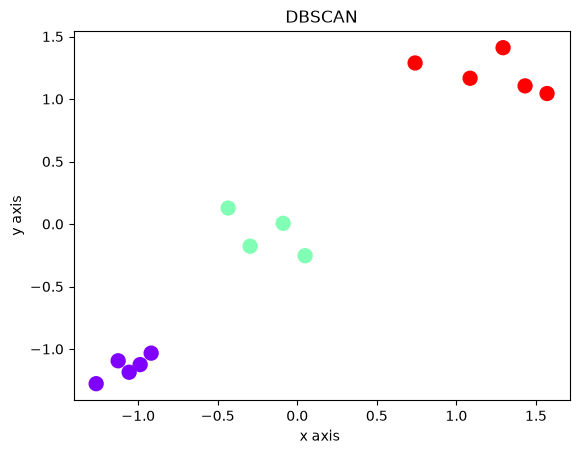

In [23]:
plt.scatter(
    [x[0] for x in X_scaled],
    [x[1] for x in X_scaled],
    c=Labels1,
    cmap='rainbow',
    s=100
)
plt.xlabel("x axis ")
plt.ylabel("y axis")
plt.title("DBSCAN")
plt.show()

In [24]:
# n_clusters=3 because we expect 3 customer segments (young/low-spend,
# mid-age/moderate-spend, senior/high-spend)
model2 = KMeans(n_clusters=3, n_init=10)
Labels2 = model2.fit_predict(X_scaled)
print(Labels2)


[1 1 1 1 0 0 1 0 0 2 2 2 2 2]


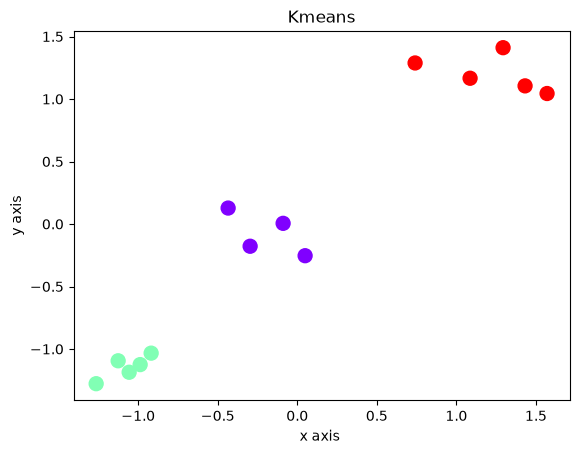

In [25]:
plt.scatter(
    [x[0] for x in X_scaled],
    [x[1] for x in X_scaled],
    c=Labels2,
    cmap='rainbow',
    s=100
)
plt.xlabel("x axis ")
plt.ylabel("y axis")
plt.title("Kmeans")
plt.show()

In [26]:
Model3 = AgglomerativeClustering(n_clusters=3)
Labels3 = Model3.fit_predict(X_scaled)
print(Labels3)


[1 1 1 1 2 2 1 2 2 0 0 0 0 0]


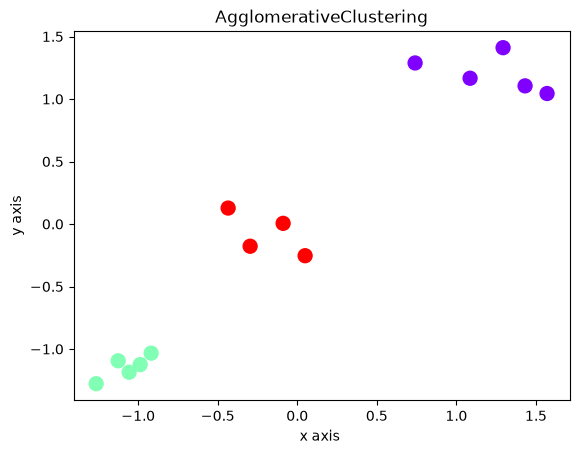

In [27]:
plt.scatter(
    [x[0] for x in X_scaled],
    [x[1] for x in X_scaled],
    c=Labels3,
    cmap='rainbow',
    s=100
)
plt.xlabel("x axis ")
plt.ylabel("y axis")
plt.title("AgglomerativeClustering")
plt.show()